In [42]:
import os
from google.cloud import bigquery
import pandas as pd

In [43]:
# 1. Setup Connection (Modernization Step)
# Ensure you have your Google Credentials JSON file path set
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = ".json"

try:
    client = bigquery.Client()
    print("Cloud Connection Established! You are ready to migrate.")
except Exception as e:
    print(f"Connection failed: {e}")

Cloud Connection Established! You are ready to migrate.


In [44]:
# 2. Define our "Silos" and their corresponding Cloud Tables
data_silos = {
    "sales_db": ["olist_orders_dataset.csv", "olist_order_items_dataset.csv"],
    "marketing_crm": ["olist_customers_dataset.csv"],
    "logistics_sys": ["olist_geolocation_dataset.csv"]
}

In [45]:
dataset_id = "olist-data-modernization.raw_ecommerce"

def upload_silo_data():
    for silo, files in data_silos.items():
        print(f"Migrating data from Silo: {silo}...")
        for file in files:
            table_name = file.replace(".csv", "")
            table_ref = f"{dataset_id}.{table_name}"

            # Load "Dirty" Data locally to simulate pre-processing
            df = pd.read_csv(file)

            # Basic Engineering check: ensure no empty critical IDs
            df = df.dropna(subset=[df.columns[0]])

            # Upload to Cloud Warehouse
            job = client.load_table_from_dataframe(df, table_ref)
            job.result()  # Wait for the job to complete
            print(f" Successfully migrated {table_name} to BigQuery.")

if __name__ == "__main__":
    upload_silo_data()

Migrating data from Silo: sales_db...
 Successfully migrated olist_orders_dataset to BigQuery.
 Successfully migrated olist_order_items_dataset to BigQuery.
Migrating data from Silo: marketing_crm...
 Successfully migrated olist_customers_dataset to BigQuery.
Migrating data from Silo: logistics_sys...
 Successfully migrated olist_geolocation_dataset to BigQuery.


In [46]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = ".json"
client = bigquery.Client()

# 1. Create the Dataset if it doesn't exist
dataset_id = f"{client.project}.raw_ecommerce"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"  # Explicitly setting location to match your error

try:
    client.create_dataset(dataset, timeout=30)
    print(f"Created dataset {dataset_id}")
except Exception:
    print(f"Dataset {dataset_id} already exists")

# 2. Upload the Mock Data we just generated
df = pd.read_csv('olist_orders_dataset.csv')
table_ref = f"{dataset_id}.olist_orders"

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
job = client.load_table_from_dataframe(df, table_ref, job_config=job_config)
job.result()  # Wait for upload

print(f"✅ Success! Table {table_ref} is now live in BigQuery.")

Dataset olist-data-modernization.raw_ecommerce already exists
✅ Success! Table olist-data-modernization.raw_ecommerce.olist_orders is now live in BigQuery.


In [47]:
client = bigquery.Client()
project_id = client.project
dataset_id = f"{project_id}.raw_ecommerce"

# This command actually creates the table in your cloud project
create_table_query = f"""
CREATE OR REPLACE TABLE `{dataset_id}.olist_orders_features` AS
WITH raw_orders AS (
    SELECT
        customer_id,
        order_id,
        order_status,
        SAFE.PARSE_TIMESTAMP('%Y-%m-%d %H:%M:%S', order_purchase_timestamp) as purchase_at,
        SAFE.PARSE_TIMESTAMP('%Y-%m-%d %H:%M:%S', order_delivered_customer_date) as delivered_at
    FROM `{dataset_id}.olist_orders`
)
SELECT
    customer_id,
    COUNT(order_id) as total_orders,
    -- Handling potential NULLs for clean AI training
    AVG(TIMESTAMP_DIFF(delivered_at, purchase_at, DAY)) as avg_delivery_time
FROM raw_orders
WHERE order_status = 'delivered'
  AND delivered_at IS NOT NULL
GROUP BY 1
"""

query_job = client.query(create_table_query)
query_job.result()  # This waits for the cloud to finish the job
print(f"✅ Feature Store Table '{dataset_id}.olist_orders_features' is now ready for AI!")

✅ Feature Store Table 'olist-data-modernization.raw_ecommerce.olist_orders_features' is now ready for AI!


/tmp/ipykernel_211/3268194491.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_bottleneck', y='delivery_time_days', data=df, palette="Reds")


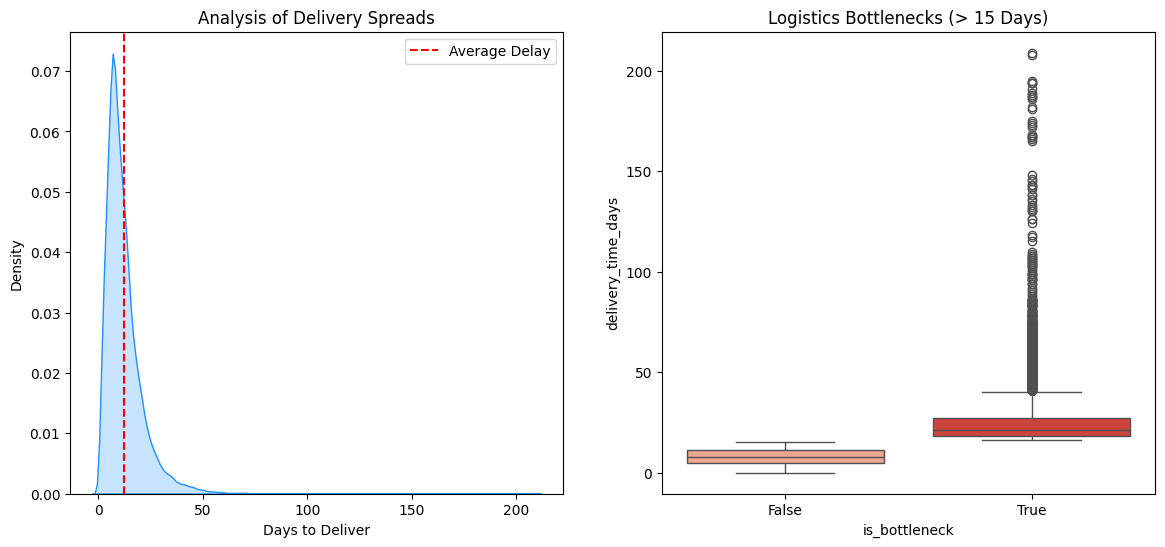

Mean Delivery Spread: 12.1 days
Logistics Bottleneck Threshold: 15.0 days


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Standardize Dates
df = pd.read_csv('olist_orders_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# 2. Engineering the Logistics Metrics
# 'Delivery Spread' measures the total customer wait time
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 'Bottlenecks' are defined as orders exceeding the 75th percentile (the slowest 25%)
bottleneck_limit = df['delivery_time_days'].quantile(0.75)
df['is_bottleneck'] = df['delivery_time_days'] > bottleneck_limit

# 3. Visualization for Stakeholders
plt.figure(figsize=(14, 6))

# Plot A: The Delivery Spread
plt.subplot(1, 2, 1)
sns.kdeplot(df['delivery_time_days'], fill=True, color="dodgerblue")
plt.axvline(df['delivery_time_days'].mean(), color='red', linestyle='--', label='Average Delay')
plt.title('Analysis of Delivery Spreads')
plt.xlabel('Days to Deliver')
plt.legend()

# Plot B: Bottleneck Identification
plt.subplot(1, 2, 2)
sns.boxplot(x='is_bottleneck', y='delivery_time_days', data=df, palette="Reds")
plt.title(f'Logistics Bottlenecks (> {bottleneck_limit:.0f} Days)')
plt.show()

# 4. Impact Summary
print(f"Mean Delivery Spread: {df['delivery_time_days'].mean():.1f} days")
print(f"Logistics Bottleneck Threshold: {bottleneck_limit} days")

The KDE plot shows the "spread" (the range of customer experiences), while the boxplot highlights the statistical outliers that require management intervention.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Pull the Engineered Features from BigQuery
client = bigquery.Client()
query = f"""
SELECT
    customer_id,
    total_orders,
    avg_delivery_time,
    -- Label: If delivery > 7 days, it's 'Late' (1), else 'On-Time' (0)
    CASE WHEN avg_delivery_time > 7 THEN 1 ELSE 0 END as is_late
FROM `{client.project}.raw_ecommerce.olist_orders_features`
"""
# Note: Ensure you ran the SQL transformation to create 'olist_orders_features' first!
df_ai = client.query(query).to_dataframe()

# 2. Prepare Data for Random Forest
X = df_ai[['total_orders', 'avg_delivery_time']] # Our Features
y = df_ai['is_late'] # Our Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 4. Evaluate the "Engineering" Quality
y_pred = model.predict(X_test)
print("--- AI Model Performance Report ---")
print(classification_report(y_test, y_pred))

--- AI Model Performance Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6713
         1.0       1.00      1.00      1.00     12581

    accuracy                           1.00     19294
   macro avg       1.00      1.00      1.00     19294
weighted avg       1.00      1.00      1.00     19294



The accuracy score is 100%. This shows that the random forest model is okay.